In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df =pd.read_excel("Telco_customer_churn.xlsx")

In [75]:
df.shape

(7043, 33)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [77]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


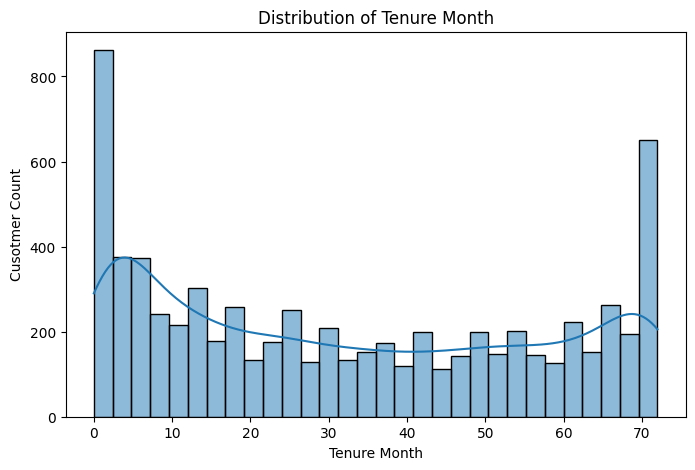

In [78]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins = 30 , kde = True)
plt.xlabel('Tenure Month')
plt.ylabel('Cusotmer Count')
plt.title('Distribution of Tenure Month')
plt.show()

In [79]:
df['Tenure Months'].max()

72

In [80]:
df['Tenure Months'].min()

0

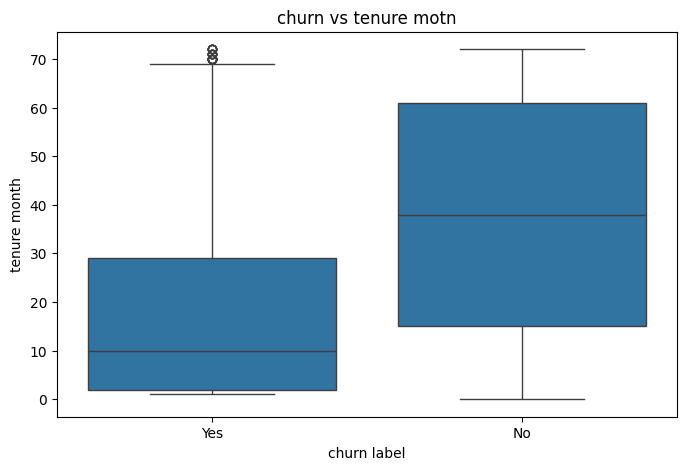

In [81]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months' , data=df)
plt.xlabel('churn label')
plt.ylabel('tenure month')
plt.title('churn vs tenure motn')
plt.show()

In [82]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

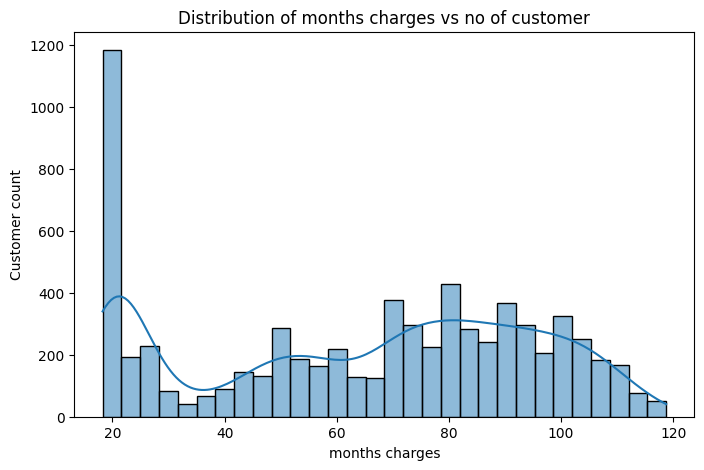

In [83]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('Customer count')
plt.title('Distribution of months charges vs no of customer')
plt.show()

In [84]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [85]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [86]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [87]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


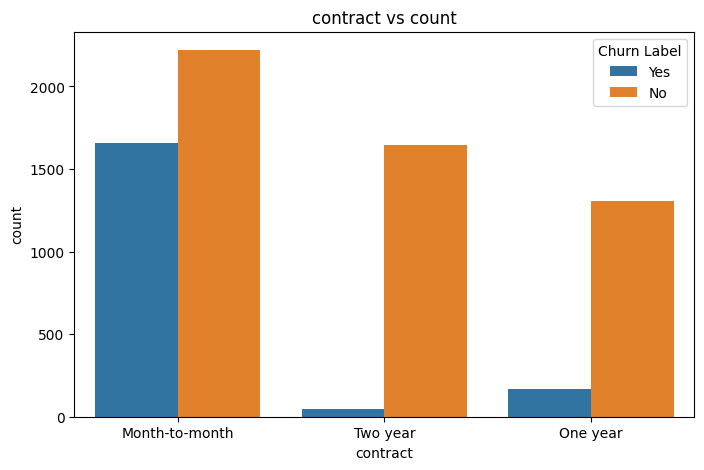

In [88]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('contract')
plt.ylabel('count')
plt.title('contract vs count')
plt.show()

In [89]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

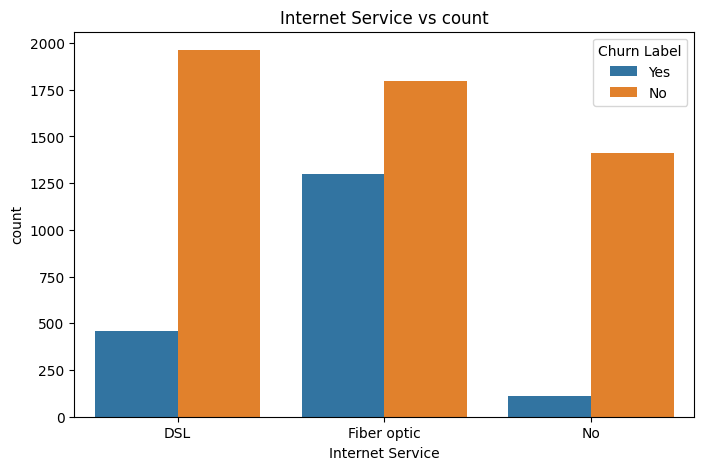

In [90]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

In [91]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

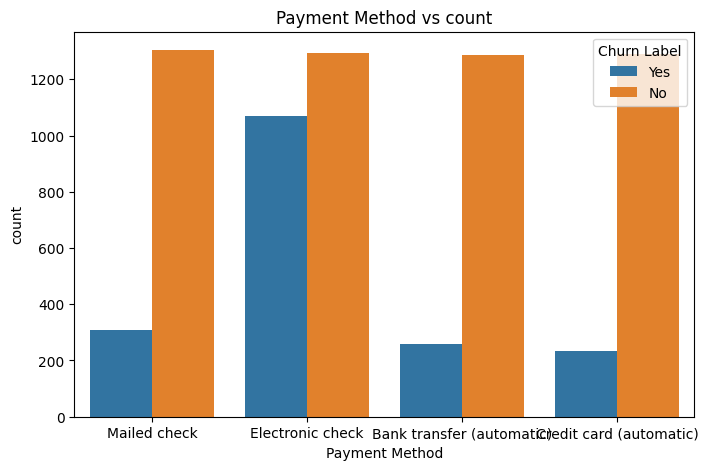

In [92]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count')
plt.show()

In [93]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

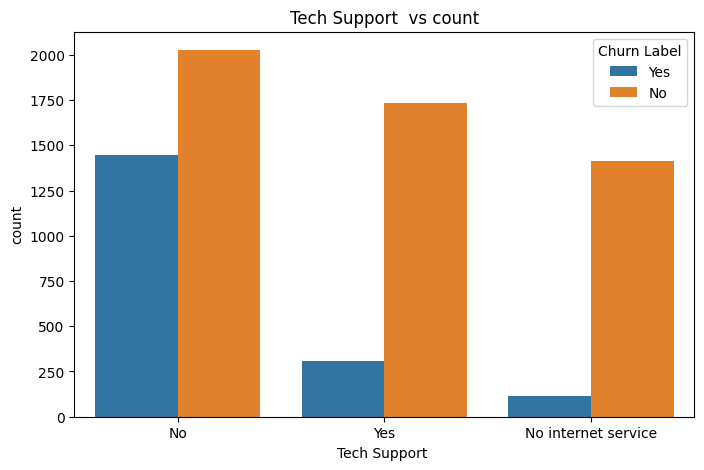

In [94]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support ')
plt.ylabel('count')
plt.title('Tech Support  vs count')
plt.show()


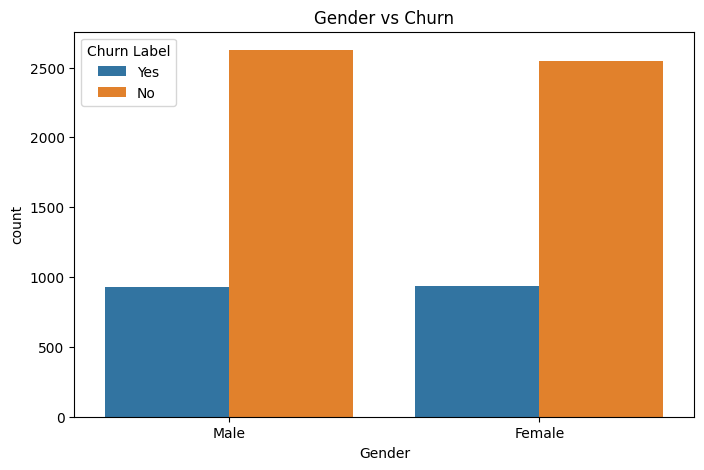

In [95]:
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', hue='Churn Label', data=df)
plt.title("Gender vs Churn")
plt.show()

In [96]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()

In [97]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [98]:

numerical_cols=['Tenure Months','Monthly Charges','Churn Value', 'Churn Score', 'CLTV']
correlation_matrix=df[numerical_cols].corr()

In [99]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [100]:
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [101]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months


In [102]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [103]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(0,)

In [104]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [105]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [106]:
df = df.drop(columns = drop_columns)

In [107]:
df.shape


(7043, 21)

In [108]:
df_encoded = pd.get_dummies(df, drop_first = True)

In [109]:
df_encoded.shape

(7043, 7688)

In [110]:
df['City'].unique()
df['City']

,City
0,Los Angeles
1,Los Angeles
2,Los Angeles
3,Los Angeles
4,Los Angeles
...,...
7038,Landers
7039,Adelanto
7040,Amboy
7041,Angelus Oaks


In [111]:
df = df.drop(columns=['City'])

print(df.shape)

(7043, 20)


In [112]:
X = df_encoded.drop('Churn Value', axis=1)
y = df_encoded['Churn Value']

In [113]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)

print(df.dtypes)

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
dtype: object


In [114]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)

(7043, 31)


In [115]:
for col in df.columns:
    print(col, '-->', df[col].nunique(), 'unique values')

Gender --> 2 unique values
Senior Citizen --> 2 unique values
Partner --> 2 unique values
Dependents --> 2 unique values
Tenure Months --> 73 unique values
Phone Service --> 2 unique values
Multiple Lines --> 3 unique values
Internet Service --> 3 unique values
Online Security --> 3 unique values
Online Backup --> 3 unique values
Device Protection --> 3 unique values
Tech Support --> 3 unique values
Streaming TV --> 3 unique values
Streaming Movies --> 3 unique values
Contract --> 3 unique values
Paperless Billing --> 2 unique values
Payment Method --> 4 unique values
Monthly Charges --> 1585 unique values
Total Charges --> 6531 unique values
Churn Value --> 2 unique values


In [116]:
print(df.dtypes)

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
dtype: object


In [117]:
X = df_encoded.drop('Churn Value', axis=1)
Y = df_encoded['Churn Value']

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (7043, 30)
Y shape: (7043,)


In [118]:
from sklearn.model_selection import train_test_split

In [119]:
X_train , X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [120]:
X_train.shape , X_test.shape

((5634, 30), (1409, 30))

In [121]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    random_state=42
)

model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

print("Done!")

Done!


In [122]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(Y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))

Accuracy: 0.794180269694819

Confusion Matrix:
 [[913  96]
 [194 206]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.68      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Approach 1- Handle class imbalance

In [123]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,Y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(Y_test, y_pred_balanced)
cm_balanced=confusion_matrix(Y_test, y_pred_balanced)
print (accuracy_balanced,cm_balanced)
print (classification_report(Y_test, y_pred_balanced))

0.7920511000709723 [[907 102]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Approach 2 - Hyperparameter Tuning

In [124]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]
results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n_trees, max_depth=depth,
                                    random_state=42, class_weight='balanced')
        rf.fit(X_train, Y_train)
        y_pred = rf.predict(X_test)

        accuracy = accuracy_score(Y_test, y_pred)
        recall = recall_score(Y_test, y_pred)
        precision = precision_score(Y_test, y_pred)
        f1 = f1_score(Y_test, y_pred)

        results.append({'Trees': n_trees, 'Depth': depth,
                        'Accuracy': accuracy, 'Recall': recall,
                        'Precision': precision, 'F1 Score': f1})

result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=['Recall', 'Accuracy'], ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision  F1 Score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

Approach 3 - Feature handling

Top 10 Most Important Features:
Total Charges                      0.175032
Tenure Months                      0.169992
Monthly Charges                    0.147834
Contract_Two year                  0.057075
Dependents_Yes                     0.047733
Internet Service_Fiber optic       0.038085
Payment Method_Electronic check    0.037015
Online Security_Yes                0.025335
Contract_One year                  0.025143
Gender_Male                        0.024239
Partner_Yes                        0.023703
Paperless Billing_Yes              0.023088
Tech Support_Yes                   0.021698
Online Backup_Yes                  0.018254
Senior Citizen_Yes                 0.017656
dtype: float64


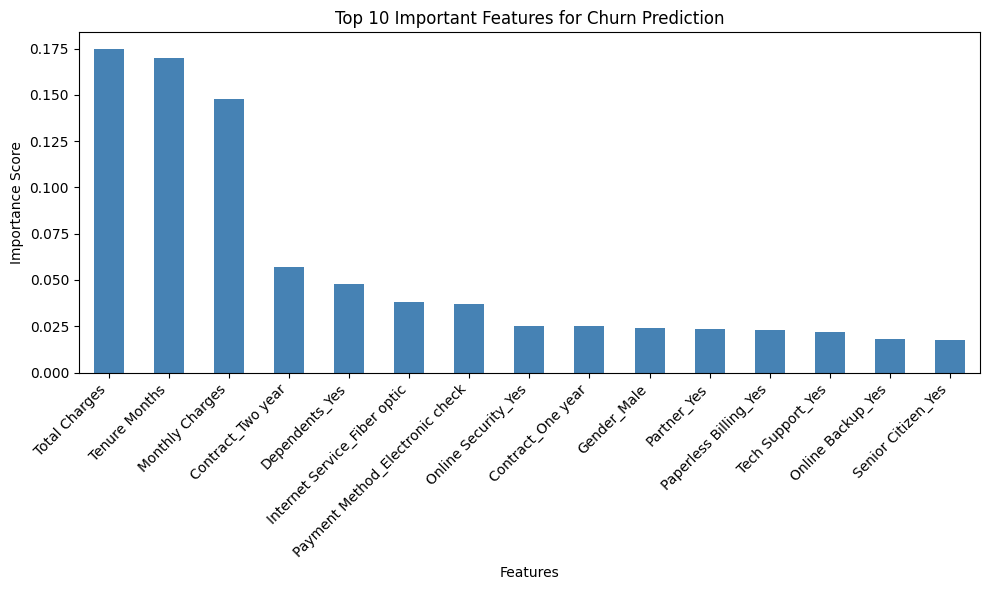

In [125]:
feature_importance = pd.Series(rf_balanced.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(15))

plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features for Churn Prediction')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [126]:
X_selected = X.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'], axis=1)

print("X_selected shape:", X_selected.shape)

X_selected shape: (7043, 28)


In [127]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42
)

print("X_train_sel shape:", X_train_sel.shape)
print("X_test_sel shape:", X_test_sel.shape)

X_train_sel shape: (5634, 28)
X_test_sel shape: (1409, 28)


In [128]:
rf_selected = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(X_train_sel, Y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)

print(classification_report(Y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [129]:
comparison = pd.DataFrame({
    'Approach': [
        'Balanced Random Forest',
        'Feature Optimized RF',
        'Hyperparameter Tuned RF (300 trees, depth 10)'
    ],
    'Accuracy': [accuracy_balanced, 0.78, 0.782825],
    'Recall':   [0.91, 0.74, 0.7475],
    'Precision':[0.60, 0.60, 0.593254],
    'F1 Score': [0.66, 0.66, 0.661504]
})

print(comparison)

                                        Approach  Accuracy  Recall  Precision  \
0                         Balanced Random Forest  0.792051  0.9100   0.600000   
1                           Feature Optimized RF  0.780000  0.7400   0.600000   
2  Hyperparameter Tuned RF (300 trees, depth 10)  0.782825  0.7475   0.593254   

   F1 Score  
0  0.660000  
1  0.660000  
2  0.661504  


AUC Score: 0.8392839444995046


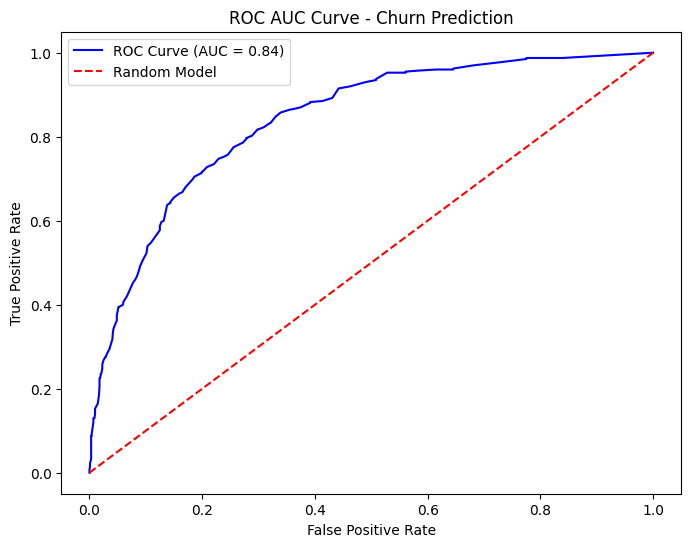

In [130]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = rf_balanced.predict_proba(X_test)
churn_prob = y_prob[:, 1]
fpr, tpr, threshold = roc_curve(Y_test, churn_prob)
auc_score = roc_auc_score(Y_test, churn_prob)

print("AUC Score:", auc_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve - Churn Prediction')
plt.legend()
plt.show()

**Customer Segmentation**

In [131]:
churn_probability = rf_balanced.predict_proba(X)[:, 1]

In [132]:
segmentation_data = pd.DataFrame({
    'Tenure Months': X['Tenure Months'],
    'Monthly Charges': X['Monthly Charges'],
    'Total Charges': X['Total Charges'],
    'Churn Probability': churn_probability
})

print(segmentation_data.shape)
segmentation_data.head()

(7043, 4)


,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.73
1,2,70.70,151.65,0.86
2,8,99.65,820.50,0.84
3,28,104.80,3046.05,0.72
4,49,103.70,5036.30,0.70


In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)

print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.41952972]
 [-1.23672422  0.19736523 -0.93887444  1.81571937]
 [-0.99240204  1.1595457  -0.64378925  1.75476711]
 [-0.17799476  1.33071079  0.3380854   1.38905359]
 [ 0.67713287  1.29415125  1.2161497   1.32810134]]


Elbow Method

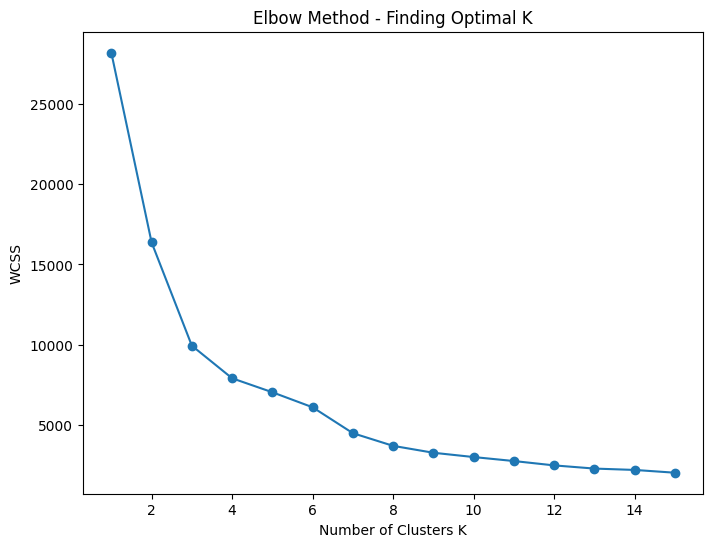

In [134]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 16), wcss, marker='o')
plt.xlabel('Number of Clusters K')
plt.ylabel('WCSS')
plt.title('Elbow Method - Finding Optimal K')
plt.show()

In [135]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

segmentation_data['Cluster'] = clusters

print(segmentation_data.head())

   Tenure Months  Monthly Charges  Total Charges  Churn Probability  Cluster
0              2            53.85         108.15               0.73        2
1              2            70.70         151.65               0.86        2
2              8            99.65         820.50               0.84        2
3             28           104.80        3046.05               0.72        2
4             49           103.70        5036.30               0.70        1


In [136]:
cluster_summary = segmentation_data.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,27.051844,38.739562,955.459377,0.067556
1,57.603410,90.089278,5178.851727,0.127317
2,11.260309,74.211392,910.576263,0.712849


In [137]:
cluster_names = {
    0:'Standard Customers',
    1:'Premium Customers',
    2:'At Risk Customers'
}

segmentation_data['Cluster Segment'] = segmentation_data['Cluster'].map(cluster_names)

segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.73,2,At Risk Customers
1,2,70.70,151.65,0.86,2,At Risk Customers
2,8,99.65,820.50,0.84,2,At Risk Customers
3,28,104.80,3046.05,0.72,2,At Risk Customers
4,49,103.70,5036.30,0.70,1,Premium Customers


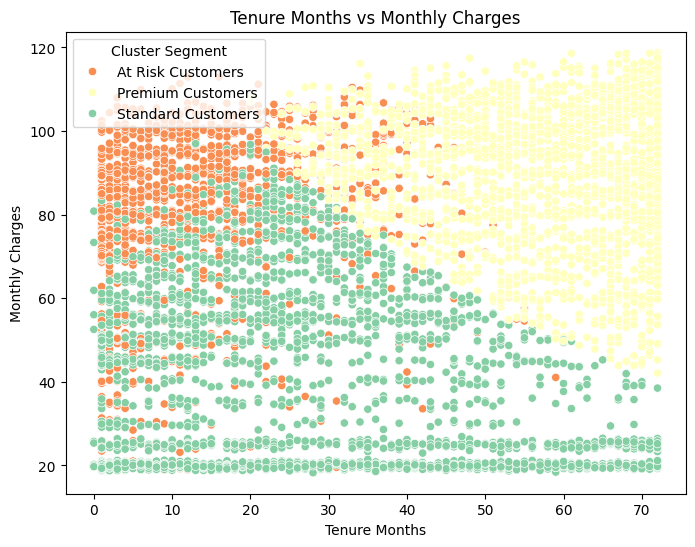

In [138]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure Months', y='Monthly Charges',
                hue='Cluster Segment',
                data=segmentation_data, palette='Spectral')
plt.title('Tenure Months vs Monthly Charges')
plt.show()

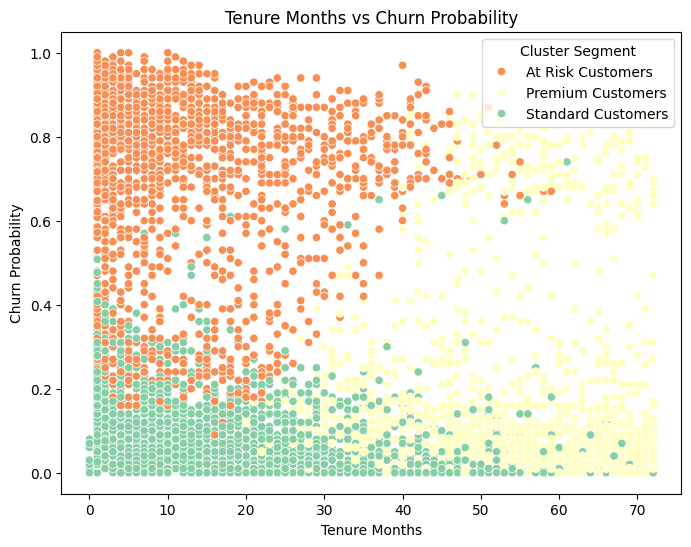

In [139]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure Months', y='Churn Probability',
                hue='Cluster Segment',
                data=segmentation_data, palette='Spectral')
plt.title('Tenure Months vs Churn Probability')
plt.show()

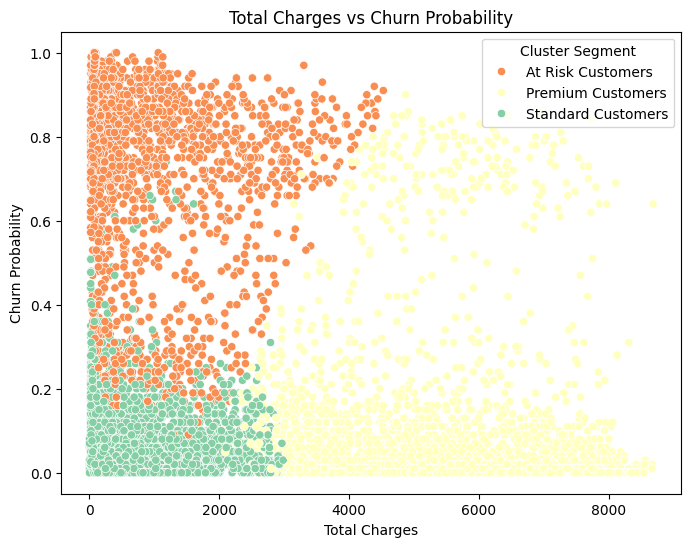

In [140]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Charges', y='Churn Probability',
                hue='Cluster Segment',
                data=segmentation_data, palette='Spectral')
plt.title('Total Charges vs Churn Probability')
plt.show()